# Module 2: Epidemic Modeling Using SEIR

## Team Members:
*Isabella Orlando and Hayden Rue*

## Project Title:
Mystery Virus Modeling Using SEIR

## Project Goal:
This project seeks to answer the question: How can the SEIR model be used to predict the peak day and number of active cases of a mystery virus when given early stage data, find the error of the prediction after the full data release, and determine the best intervention methods to implement for other outbreaks of the same or similar viruses?

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis

### 2a. Methods

This project used a combination of exponential growth and SEIR  modeling to analyze and predict the trajectory of a mystery virus outbreak in a population of 17,900 people. Early stage data (through day 45) was fit to an exponential curve to estimate the initial growth rate (R0). The SEIR model was then solved numerically using Euler's method with a daily time step, dividing the population into Susceptible, Exposed, Infectious, and Recovered compartments. Model parameters (β, γ, σ) were then optimized by minimizing the sum of squared error (SSE) between the model output and observed active case counts via grid search. The fitted model was then projected forward to predict the peak day and total active cases of the outbreak, and later validated against the full dataset released in data release #3


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
Using the data gained from data release #1, the number of active cases was plotted through day 45. 

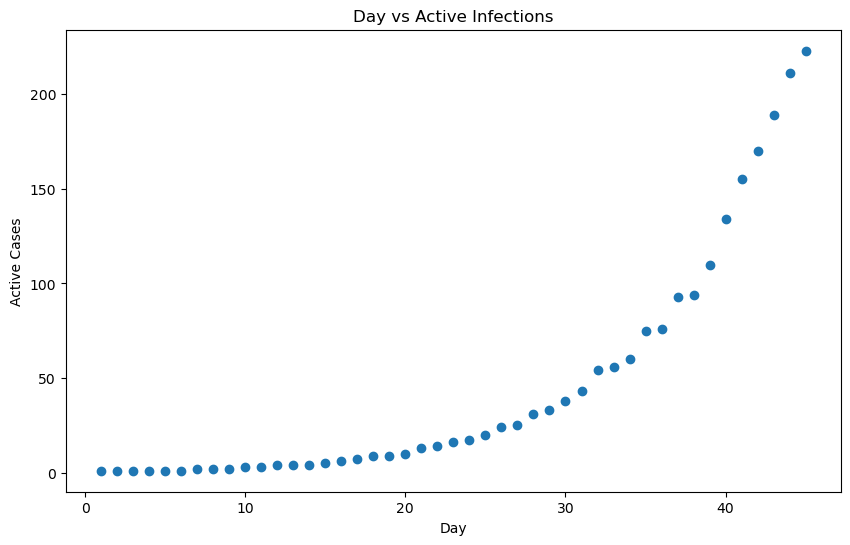

In [2]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

#%%
# Create and label a plot of the active cases over time
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.show()

Trends and key points from the data:
* The initial number of infections is small but begins to increase rapidly around day 25
* The curve of the graph suggests exponential growth because as the number of infected individuals increases so does the total number of new infections in a nonlinear fashion
* We could measure how quickly the virus is spreading through the growth rate, doubling time, and an average transmission rate to determine how quickly the virus is spreading
* Knowing how contagious the virus is, population size, presence of immunity, and the length of infectious period, both symptomatic and asymptomatic, will be helpful in predicting an accurate curve for the outbreak

Estimated r: 0.131365895627797
Estimated I0: 0.7111198627565817
Estimated R0: 1.9286677472085472


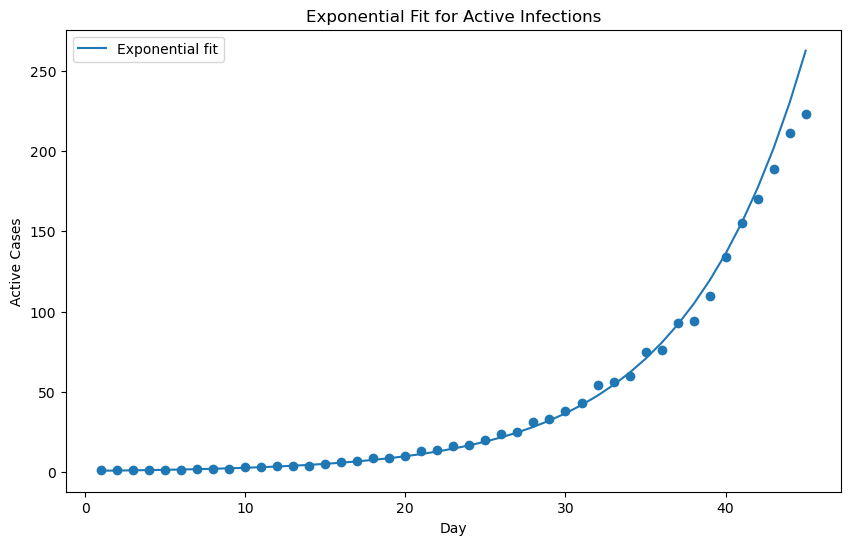

In [3]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

import numpy as np

#Get values from variables in csv
t = df["day"].values
I = df["active reported daily cases"].values

#only examine first 45 days for early exponential growth
mask = t <= 45
t_exp = t[mask]
I_exp = I[mask]

#%%
#linearize to use polyfit and get r from slope

# Remove zeros before log
positive_mask = I_exp > 0
t_fit = t_exp[positive_mask]
I_fit = I_exp[positive_mask]

log_I = np.log(I_fit)

# Linear regression
coeffs = np.polyfit(t_fit, log_I, 1)
r = coeffs[0]
log_I0 = coeffs[1]
I0 = np.exp(log_I0)

# print growth rate and estimated initial infections
print("Estimated r:", r)
print("Estimated I0:", I0)

#%%
#Estimate R0

D = 5
R0 = np.exp(r * D)

print("Estimated R0:", R0)


#%%
# Create and label a plot of the active cases over time with exponential fit for growth rate

I_model = I0 * np.exp(r * t)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(t, I_model, label = "Exponential fit")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Exponential Fit for Active Infections')
plt.legend()
plt.show()

Due to the exponential nature of the data, an exponential fit was used to determine the R0 value and represent the early growth rate of the virus. The data was linearized using a logarithmic function to perform the fit. The Estimated R0 value was 1.9286677472085472, signifing that approximately 2 people will become infected for every person infected through this early stage of the outbreak. The R0 estimate value is likely accurate since the data strongly resembles an expoenetial curve.


To help predict the trend of the data beyond day 45, we can compare the R0 from the mystery virus to other known R0s. Ebola and EV-D68 are viruses that have similar R0s around 2.

Ebola is an often fatal virus that results in hemorrhagic illness. It is believed to come from fruit bats with periodic outbreaks present in Central and West Africa.

EV-D68 is a virus that causes respiratory illness, ranging from mild to severe depending on the susceptibility of the person infected. The virus was originally rare, however outbreaks have increased and are showing symptoms related to neurological conditions and muscle weakness


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
The SEIR model was solved using Euler's method with a step size of h=1 day. The model divides the sample population (17,900) into Susceptible, Exposed, Infectious, and Recovered with the initial conditions of one infected.

For each step, the following differential equations were approximated:

* dS/dt = −(β · S · I) / N
* dE/dt = (β · S · I) / N − σE
* dI/dt = σE − γI
* dR/dt = γI

β represents transmission rate, σ is 1/incubation period, and γ is the recovery rate. Each compartment of the model was updated by added the product of the derivative and the step size for each day.

In [4]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
To fit the SEIR model to the data from release #2, a grid search optimization of the parameteres β, σ, and γ was performed. To inform the parameter ranges used for the search, the R0 estimate was used from the early exponential data since R0 = β/γ.

Search ranges:

* β: 0.1 to 0.5 (10 values)
* γ: 0.05 to 0.2 (10 values)
* σ: 0.1 to 0.5 (10 values)

For each set of parameters, Euler's method was run and the resulting output was compared to active cases using the sum of squared error(SSE). The combinations that minimized SSE were determined to be optimal.

Optimal values:

β = 0.5
γ = 0.2
σ ≈ 0.322

This gives a new fitted R0 of 2.5, which is relatively consistent with the early-stage estimate of 1.93. The discrepancy is caused by the inclusion of σ in the SEIR model, where the initial estimate used e^(r*D), where D was assumed to be 5 days. If the true infectious period differs from 5, the initial R0 estimate will be directly effected. Also, the esponential fit only used data through day 45, whereas the SEIR model was able to take data through day 70, improving its accuracy.


In [5]:
# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

Optimal Beta: 0.5
Optimal Sigma: 0.32222222222222224
Optimal Gamma: 0.2
Optimal SSE: 139513.53806278316


### 2e. Plot the model-predicted infections over time compared to the data.
The optimal parameters from the grid search were used to plot the SEIR predictions of active cases through day 70 from the data of release #2. The model curve generally follows the data well during the early exponential growth phase, but begins to deviate as the days increase beyond 45. The new fit confirms the optimal parameters produce a resonable approximation of the outbreak trend up to this point.

Optimal Beta: 0.5
Optimal Sigma: 0.32222222222222224
Optimal Gamma: 0.2
Optimal SSE: 139513.53806278316


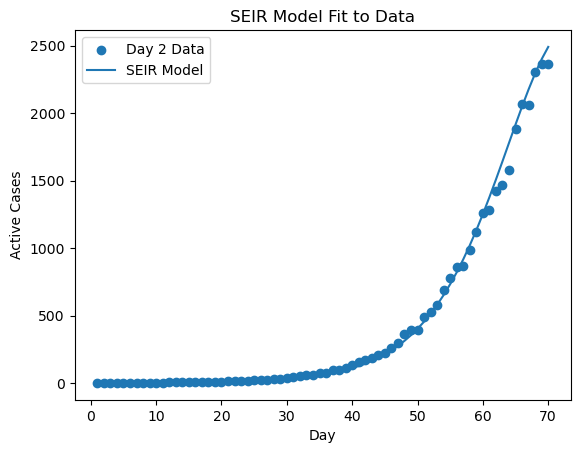

In [6]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Plot the model vs given data
plt.figure()
plt.scatter(day, active, label ="Day 2 Data")
plt.plot(day, I_best[:len(day)], label ="SEIR Model")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()



### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
Using the optimal SEIR parameters, the model was projected forward to 200 days to predict the full trajectory of the outbreak. The peak number of active infections was identified by finding the maximum of the predicted I(t) curve. The model predicted a peak of approximately 2,652 active cases occurring on day 73.


Optimal Beta: 0.5
Optimal Sigma: 0.32222222222222224
Optimal Gamma: 0.2
Optimal SSE: 139513.53806278316
Peak infections: 2651.858284444435
Peak occurs on day: 73


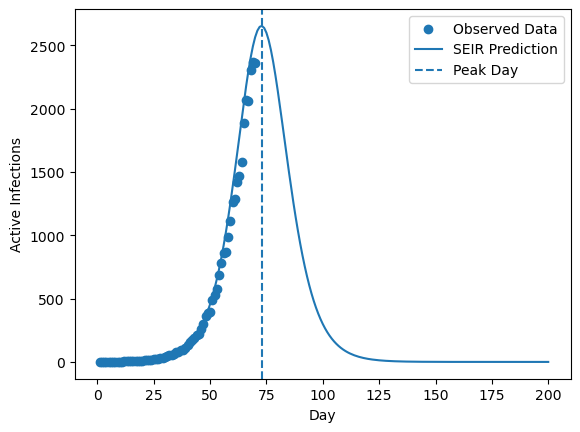

In [7]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Predict future trends
future_days = 200

#Run eulers method on future days and find peak infections and peak day
I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days)
peak_infections = np.max(I_future)
peak_day = np.argmax(I_future)
print("Peak infections:", peak_infections)
print("Peak occurs on day:", peak_day)

plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.axvline(peak_day, linestyle="--", label="Peak Day")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.legend()
plt.show()

The peak number of active infections(2,652) occuring at day 73 is a resonable prediction considering the large population size of 17,900. This means about 15% of the population is infected on the peak, or 73rd day.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
From the release of the full dataset (Data release #3), the SEIR model predictions were compared vs the true active cases through day 121. The optimal parameters from the grid search were applied to the full 121 days. The model predicted a peak on day 73 with 2,652 active cases, while the true data showed a peak on  day 82 with ~3,200 active cases, yielding a relative error of ~12% for peak day and ~19.5% for peak active cases. The discrepancy is likely attributable to the limited parameter combinations tested of the grid search as well as the inherent limitations of Euler's method accumulating numerical error over long time intervals.

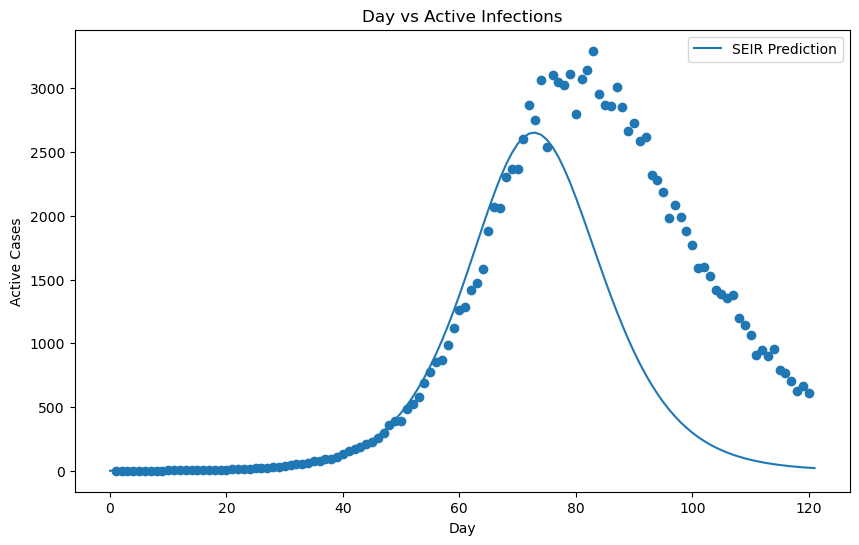

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

days = 121
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Load data from csv file
#df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv")
day = df["day"].values
active = df["active reported daily cases"].values

def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


optimal_beta = .5
optimal_gamma = .2
optimal_sigma = .32222222222

I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, days)

plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.legend()
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

RK4 method in future work
Discrepency in def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] function parameters